In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [42]:
# --------------------------------------------------
# Tweets
# --------------------------------------------------

tweets = pd.read_csv(
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\tweets_v2.csv",
    parse_dates=["timestamp_utc"]
)

# --------------------------------------------------
# WTI OHLC
# --------------------------------------------------

wti = pd.read_csv(
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\wti_v2.csv",
    parse_dates=["timestamp_utc"]
)

wti = wti.sort_values("timestamp_utc")
wti = wti.set_index("timestamp_utc")

In [43]:
wti.head()

,open,high,low,close
timestamp_utc,,,,
2011-01-03 01:15:00+00:00,91.28,91.29,91.26,91.26
2011-01-03 01:16:00+00:00,91.26,91.26,91.25,91.26
2011-01-03 01:17:00+00:00,91.25,91.26,91.25,91.26
2011-01-03 01:18:00+00:00,91.27,91.27,91.26,91.26
2011-01-03 01:19:00+00:00,91.25,91.25,91.25,91.25


In [44]:
wti['log_price'] = np.log(wti['close'])
wti['return'] = wti['log_price'].diff()

In [45]:
EVENT_WINDOW = 60  # minutes after tweet
PRE_WINDOW = 60    # optional

In [46]:
def get_event_window_returns(tweet_time, data, window=60):
    """
    Extract returns around event time.
    """
    
    start = tweet_time
    end = tweet_time + pd.Timedelta(minutes=window)

    event_data = data.loc[start:end].copy()

    if len(event_data) < 5:
        return None

    event_data['t'] = (event_data.index - tweet_time).total_seconds() / 60

    return event_data[['return', 't']]

In [47]:
all_events = []

for t in tweets['timestamp_utc']:
    event_df = get_event_window_returns(t, wti, window=60)
    
    if event_df is not None:
        event_df['event_id'] = t
        all_events.append(event_df)

events = pd.concat(all_events)

In [48]:
wti['expected_return'] = wti['return'].rolling(60).mean()
wti['abnormal_return'] = wti['return'] - wti['expected_return']

In [50]:
event_abnormal = []

for t in tweets['timestamp_utc']:
    start = t
    end = t + pd.Timedelta(minutes=60)
    
    temp = wti.loc[start:end].copy()
    
    if len(temp) < 5:
        continue
        
    temp['t'] = (temp.index - t).total_seconds() / 60
    event_abnormal.append(temp[['t', 'abnormal_return']])

event_abnormal = pd.concat(event_abnormal)

In [51]:
aar = event_abnormal.groupby('t')['abnormal_return'].mean()

In [52]:
car = aar.cumsum()

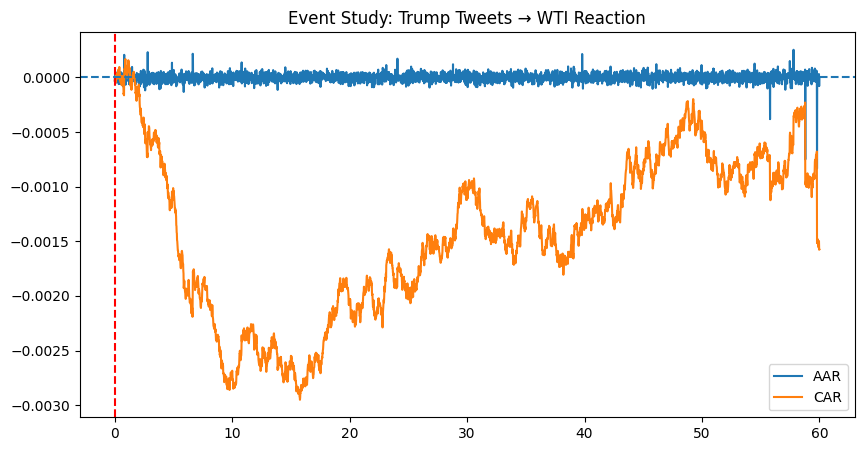

In [53]:
plt.figure(figsize=(10,5))
plt.plot(aar.index, aar.values, label="AAR")
plt.plot(car.index, car.values, label="CAR")

plt.axhline(0, linestyle='--')
plt.axvline(0, color='red', linestyle='--')

plt.title("Event Study: Trump Tweets → WTI Reaction")
plt.legend()
plt.show()

In [54]:
t_stat, p_value = stats.ttest_1samp(
    event_abnormal['abnormal_return'].dropna(),
    0
)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: -0.7397780388444791
p-value: 0.4594347775072523


In [55]:
t_stat, p_value = stats.ttest_1samp(
    car.dropna(),
    0
)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: -116.20389417461492
p-value: 0.0


## Anderer Ansatz

In [68]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [69]:
# --------------------------------------------------
# Tweets
# --------------------------------------------------

tweets = pd.read_csv(
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\tweets_v2.csv",
    parse_dates=["timestamp_utc"]
)

# --------------------------------------------------
# WTI OHLC
# --------------------------------------------------

wti = pd.read_csv(
    r"C:\Users\02_Florian_Benutzer\Desktop\trump_oil_analysis_v2\00_data\wti_v2.csv",
    parse_dates=["timestamp_utc"]
)

wti = wti.sort_values("timestamp_utc")
wti = wti.set_index("timestamp_utc")

In [70]:
tweets = tweets.sort_values('timestamp_utc')

In [71]:
prices = wti.copy()

In [75]:
prices['log_price'] = np.log(prices['close'])
prices['ret'] = prices['log_price'].diff()

In [76]:
def get_event_window(tweet_time, prices, window=60):
    start = tweet_time - pd.Timedelta(minutes=window)
    end = tweet_time + pd.Timedelta(minutes=window)
    
    window_df = prices.loc[start:end].copy()
    
    if len(window_df) < 10:
        return None
    
    window_df = window_df.reset_index()
    window_df['t'] = (window_df['timestamp_utc'] - tweet_time).dt.total_seconds() / 60
    
    return window_df[['t', 'ret']]

In [77]:
global_mean_return = prices['ret'].mean()

def compute_ar(window_df):
    df = window_df.copy()
    df['ar'] = df['ret'] - global_mean_return
    return df

In [78]:
def compute_car(ar_df):
    return ar_df['ar'].sum()

In [79]:
window_size = 60

cars = []
event_panel = []

for _, tweet in tweets.iterrows():
    window_df = get_event_window(tweet['timestamp_utc'], prices, window_size)
    
    if window_df is None:
        continue
    
    ar_df = compute_ar(window_df)
    car = compute_car(ar_df)
    
    cars.append({
        'timestamp_utc': tweet['timestamp_utc'],
        'CAR': car
    })
    
    ar_df['event_id'] = tweet['timestamp_utc']
    event_panel.append(ar_df)

car_df = pd.DataFrame(cars)
event_panel = pd.concat(event_panel)

In [80]:
print("Mean CAR:", car_df['CAR'].mean())
print("Std CAR:", car_df['CAR'].std())

Mean CAR: -2.2285062354672194e-05
Std CAR: 0.00903217964853808


In [81]:
t_stat, p_val = stats.ttest_1samp(car_df['CAR'], 0)

print("t-stat:", t_stat)
print("p-value:", p_val)

t-stat: -0.4727882875203699
p-value: 0.6363670412835589


In [82]:
def bootstrap_test(data, n=10000):
    observed = data.mean()
    
    boots = []
    for _ in range(n):
        sample = data.sample(frac=1, replace=True)
        boots.append(sample.mean())
    
    p = np.mean(np.abs(boots) >= np.abs(observed))
    return observed, p

mean_car, p_boot = bootstrap_test(car_df['CAR'])

print("Bootstrap mean CAR:", mean_car)
print("Bootstrap p-value:", p_boot)

Bootstrap mean CAR: -2.2285062354672194e-05
Bootstrap p-value: 0.6596


In [83]:
avg_ar = event_panel.groupby('t')['ar'].mean()

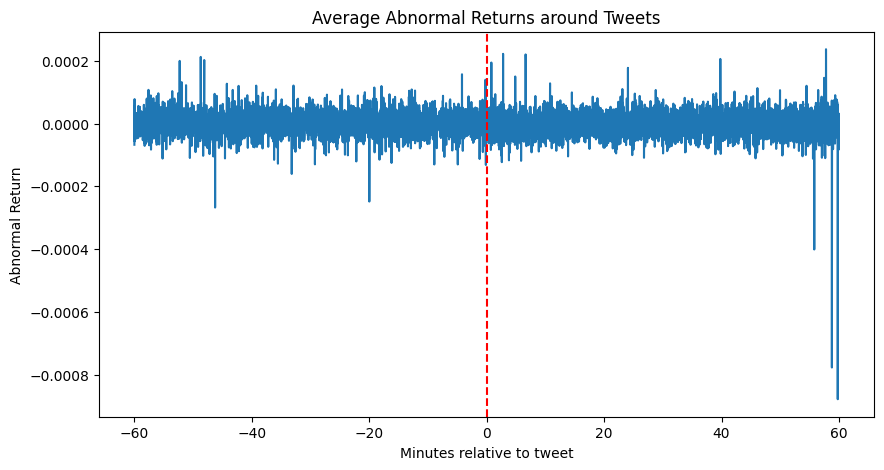

In [84]:
plt.figure(figsize=(10,5))
plt.plot(avg_ar.index, avg_ar.values)
plt.axvline(0, color='red', linestyle='--')
plt.title("Average Abnormal Returns around Tweets")
plt.xlabel("Minutes relative to tweet")
plt.ylabel("Abnormal Return")
plt.show()

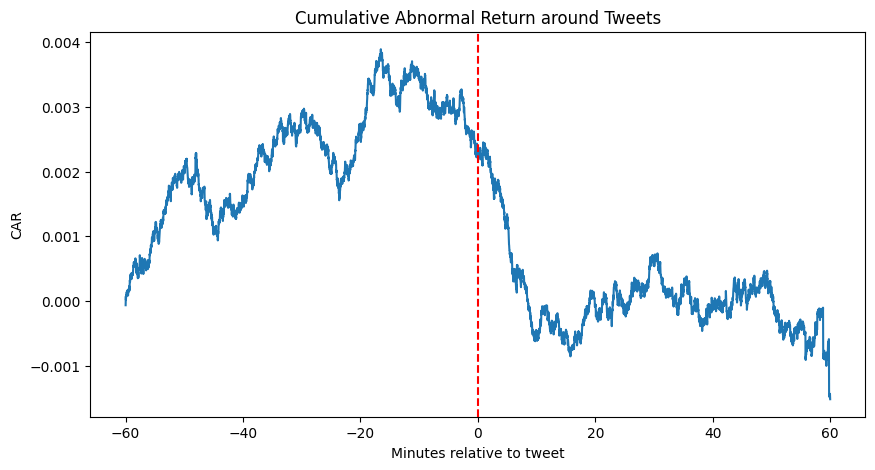

In [85]:
car_curve = avg_ar.cumsum()

plt.figure(figsize=(10,5))
plt.plot(car_curve.index, car_curve.values)
plt.axvline(0, color='red', linestyle='--')
plt.title("Cumulative Abnormal Return around Tweets")
plt.xlabel("Minutes relative to tweet")
plt.ylabel("CAR")
plt.show()

In [86]:
pre = event_panel[event_panel['t'] < 0]['ar'].mean()
post = event_panel[event_panel['t'] >= 0]['ar'].mean()

print("Pre-event AR:", pre)
print("Post-event AR:", post)

t_stat, p_val = stats.ttest_ind(
    event_panel[event_panel['t'] < 0]['ar'],
    event_panel[event_panel['t'] >= 0]['ar'],
    equal_var=False
)

print("Pre vs Post p-value:", p_val)

Pre-event AR: 6.113485441508516e-07
Post-event AR: -1.0585861634929186e-06
Pre vs Post p-value: 0.049184141839037694


In [87]:
window_vol = 60  # rolling volatility window

prices['vol'] = prices['ret'].rolling(window_vol).std()

prices['adj_ret'] = prices['ret'] / prices['vol']
prices = prices.dropna()

In [96]:
def get_event_window(tweet_time, prices, window=60):
    start = tweet_time - pd.Timedelta(minutes=window)
    end = tweet_time + pd.Timedelta(minutes=window)
    
    df = prices.loc[start:end].copy()
    
    if len(df) < 10:
        return None
    
    df = df.reset_index()
    df['t'] = (df['timestamp_utc'] - tweet_time).dt.total_seconds() / 60
    
    return df[['t', 'adj_ret']]

In [89]:
def compute_car(df, start, end):
    sub = df[(df['t'] >= start) & (df['t'] <= end)]
    return sub['adj_ret'].sum()

In [97]:
windows = [(0,5), (0,15), (0,30), (0,60)]

results = {w: [] for w in windows}
event_panel = []

for _, tweet in tweets.iterrows():
    window_df = get_event_window(tweet['timestamp_utc'], prices, 60)
    
    if window_df is None:
        continue
    
    for w in windows:
        car = compute_car(window_df, w[0], w[1])
        results[w].append(car)
    
    window_df['event_id'] = tweet['timestamp_utc']
    event_panel.append(window_df)

event_panel = pd.concat(event_panel)

In [98]:
from scipy import stats

for w, vals in results.items():
    t_stat, p_val = stats.ttest_1samp(vals, 0)
    print(f"Window {w}:")
    print("  mean:", np.mean(vals))
    print("  p-value:", p_val)

Window (0, 5):
  mean: -0.024783227973667363
  p-value: 0.021789672400815002
Window (0, 15):
  mean: -0.05586078991832634
  p-value: 0.002422033479513129
Window (0, 30):
  mean: -0.036592100412259264
  p-value: 0.1544276962884085
Window (0, 60):
  mean: -0.037736287918444224
  p-value: 0.2908643817589597


In [99]:
def bootstrap_test(data, n=10000):
    observed = np.mean(data)
    
    boots = []
    for _ in range(n):
        sample = np.random.choice(data, size=len(data), replace=True)
        boots.append(np.mean(sample))
    
    p = np.mean(np.abs(boots) >= np.abs(observed))
    
    return observed, p

In [100]:
for w, vals in results.items():
    mean, p = bootstrap_test(np.array(vals))
    print(f"Bootstrap {w}: mean={mean}, p={p}")

Bootstrap (0, 5): mean=-0.024783227973667363, p=0.4977
Bootstrap (0, 15): mean=-0.05586078991832634, p=0.5025
Bootstrap (0, 30): mean=-0.036592100412259264, p=0.5063
Bootstrap (0, 60): mean=-0.037736287918444224, p=0.5092


In [101]:
def placebo_test(prices, tweets, window=60):
    fake_cars = []
    
    random_times = np.random.choice(prices.index, size=len(tweets), replace=False)
    
    for t in random_times:
        window_df = get_event_window(t, prices, window)
        
        if window_df is None:
            continue
        
        car = window_df['adj_ret'].sum()
        fake_cars.append(car)
    
    return np.mean(fake_cars)

In [102]:
real_mean = np.mean(results[(0,15)])

placebos = [placebo_test(prices, tweets) for _ in range(500)]

p_placebo = np.mean(np.abs(placebos) >= np.abs(real_mean))

print("Real mean CAR:", real_mean)
print("Placebo p-value:", p_placebo)

KeyboardInterrupt: 

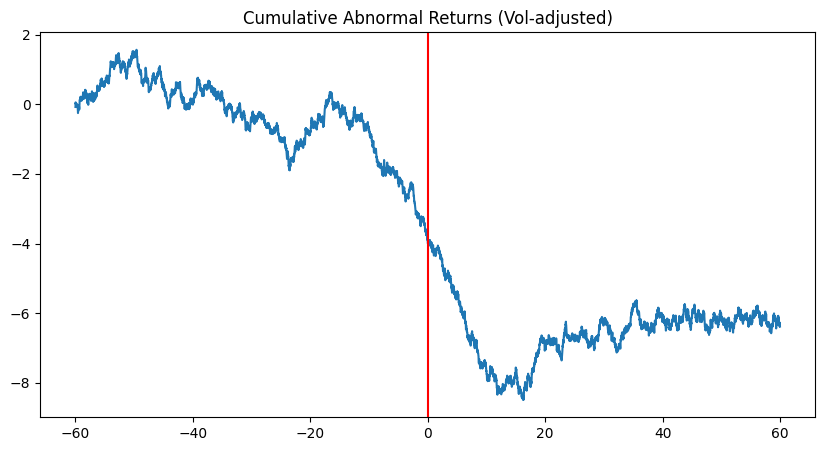

In [103]:
avg_ar = event_panel.groupby('t')['adj_ret'].mean()
car_curve = avg_ar.cumsum()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(car_curve.index, car_curve.values)
plt.axvline(0, color='red')
plt.title("Cumulative Abnormal Returns (Vol-adjusted)")
plt.show()